
# EDA - Exploratory Data Analysis pièces 3D 


In [1]:
import os
import pandas as pd
import cadquery as cq

# Chemin vers le dossier contenant les fichiers STEP
dossier_stp = "./3D"

# Initialisation d'une liste pour stocker les données
data = []

# Parcourir tous les fichiers dans le dossier
for fichier in os.listdir(dossier_stp):
    if fichier.endswith(".stp") or fichier.endswith(".step"):
        path_to_stp_file = os.path.join(dossier_stp, fichier)
        try:
            # Charger le modèle 3D à partir du fichier STEP
            model = cq.importers.importStep(path_to_stp_file)
            shape = model.val()

            # Extraire les caractéristiques
            volume = shape.Volume()
            surface = shape.Area()
            bbox = shape.BoundingBox()
            longueur, largeur, hauteur = bbox.xlen, bbox.ylen, bbox.zlen
            faces = len(shape.Faces())
            aretes = len(shape.Edges())
            sommets = len(shape.Vertices())

            # Ajouter au DataFrame
            data.append({
                "Fichier": fichier,
                "Vol": volume,
                "Surf": surface,
                "Lng_BBox": longueur,
                "Lrg_BBox": largeur,
                "Ht_BBox": hauteur,
                "Faces": faces,
                "Aretes": aretes,
                "Sommets": sommets
            })
        except Exception as e:
            print(f"Erreur lors du traitement du fichier {fichier}: {e}")

# Créer un DataFrame à partir des données
df = pd.DataFrame(data)


In [2]:
df

,Fichier,Vol,Surf,Lng_BBox,Lrg_BBox,Ht_BBox,Faces,Aretes,Sommets
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,213,624,414
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,213,624,414
2,AR00000233649--D.stp,7.930359e+06,1.821287e+06,579.000000,526.500000,539.500305,608,1574,1034
3,AR00000242305.stp,4.678052e+05,1.759273e+05,519.428775,247.348414,279.982795,205,521,322
4,AR00000242310.stp,2.802220e+05,1.048190e+05,290.000000,227.000000,25.000000,114,304,184
5,AR00000242311.stp,4.401390e+05,1.730978e+05,290.000000,432.700664,25.196153,270,846,564
6,AR00000242312.stp,7.608478e+04,3.047107e+04,144.000000,44.000000,80.000000,44,132,88
7,AR00000242313.stp,8.318124e+04,3.353410e+04,201.874338,66.000000,177.874687,96,264,170
8,AR00000243830.stp,2.171113e+05,8.426894e+04,320.616518,205.000000,151.101007,112,318,210
9,AR00000244409.stp,1.678704e+05,6.271524e+04,245.000000,86.631812,187.781038,100,266,168


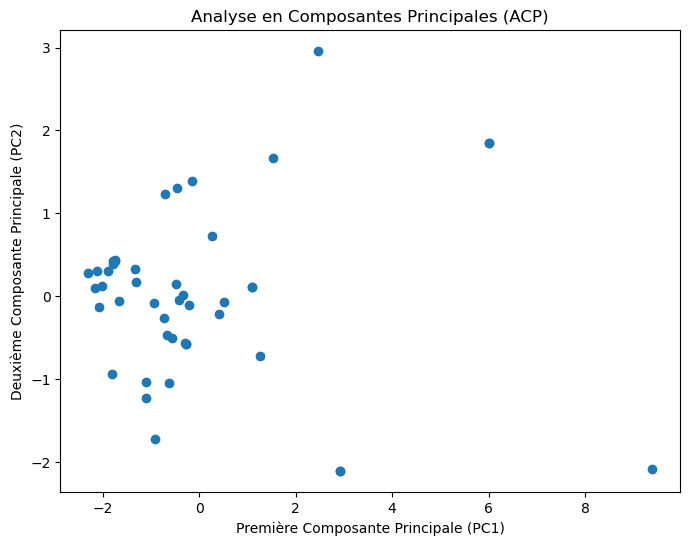

In [3]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Supposons que 'df' est ton DataFrame

# Sélectionner les colonnes numériques pour l'ACP
df_num = df.select_dtypes(include=['float64', 'int64'])

# Normalisation des données
scaler = StandardScaler()
df_norm = scaler.fit_transform(df_num)

# Application de l'ACP
pca = PCA(n_components=2)  # Utiliser 2 composantes pour la visualisation
principalComponents = pca.fit_transform(df_norm)

# Création d'un DataFrame pour les composantes principales
df_pca = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# Visualisation des résultats
plt.figure(figsize=(8,6))
plt.scatter(df_pca['PC1'], df_pca['PC2'])
plt.xlabel('Première Composante Principale (PC1)')
plt.ylabel('Deuxième Composante Principale (PC2)')
plt.title('Analyse en Composantes Principales (ACP)')
plt.show()


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include=['float64', 'int64']))


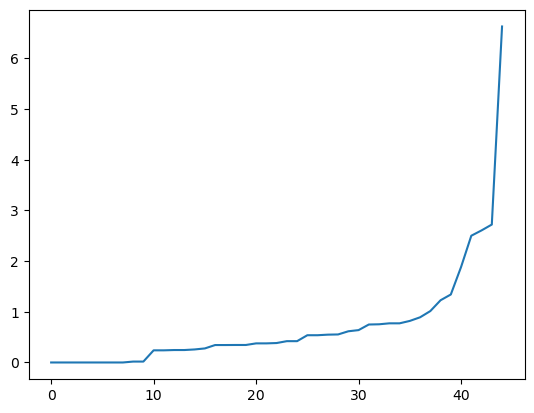

In [5]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

distances = np.sort(distances, axis=0)
distances = distances[:, 1]
plt.plot(distances)
plt.show()


In [6]:
from sklearn.cluster import DBSCAN
import pandas as pd

# Sélectionner les colonnes numériques pour le clustering
df_num = df.select_dtypes(include=['float64', 'int64'])

# Application de DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)  # eps et min_samples à ajuster
df['Cluster'] = dbscan.fit_predict(df_num)

# Afficher les résultat
df

,Fichier,Vol,Surf,Lng_BBox,Lrg_BBox,Ht_BBox,Faces,Aretes,Sommets,Cluster
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,213,624,414,-1
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,213,624,414,-1
2,AR00000233649--D.stp,7.930359e+06,1.821287e+06,579.000000,526.500000,539.500305,608,1574,1034,-1
3,AR00000242305.stp,4.678052e+05,1.759273e+05,519.428775,247.348414,279.982795,205,521,322,-1
4,AR00000242310.stp,2.802220e+05,1.048190e+05,290.000000,227.000000,25.000000,114,304,184,-1
5,AR00000242311.stp,4.401390e+05,1.730978e+05,290.000000,432.700664,25.196153,270,846,564,-1
6,AR00000242312.stp,7.608478e+04,3.047107e+04,144.000000,44.000000,80.000000,44,132,88,-1
7,AR00000242313.stp,8.318124e+04,3.353410e+04,201.874338,66.000000,177.874687,96,264,170,-1
8,AR00000243830.stp,2.171113e+05,8.426894e+04,320.616518,205.000000,151.101007,112,318,210,-1
9,AR00000244409.stp,1.678704e+05,6.271524e+04,245.000000,86.631812,187.781038,100,266,168,-1


In [7]:
df["Cluster"].value_counts()

Cluster
-1    45
Name: count, dtype: int64

[t-SNE] Computing 44 nearest neighbors...
[t-SNE] Indexed 45 samples in 0.001s...
[t-SNE] Computed neighbors for 45 samples in 0.597s...
[t-SNE] Computed conditional probabilities for sample 45 / 45
[t-SNE] Mean sigma: 4.283217
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.172455
[t-SNE] KL divergence after 300 iterations: 0.004650


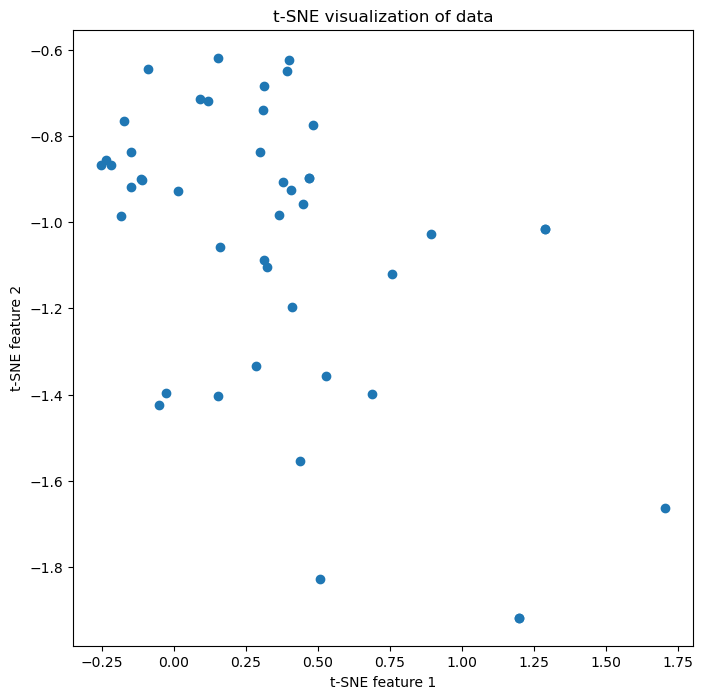

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Supposons que 'df_scaled' est ton DataFrame normalisé

# Application de t-SNE
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_results = tsne.fit_transform(df_scaled)

# Création d'un DataFrame pour les résultats de t-SNE
df_tsne = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])

# Si tu as déjà les labels de clustering (par exemple de DBSCAN)
# df_tsne['Cluster'] = df['Cluster']  # Décommente cette ligne si tu as les labels

# Visualisation des résultats
plt.figure(figsize=(8,8))
plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'])
plt.xlabel('t-SNE feature 1')
plt.ylabel('t-SNE feature 2')
plt.title('t-SNE visualization of data')

# Si tu as les labels de clustering, tu peux les utiliser pour colorier les points
# plt.scatter(df_tsne['TSNE1'], df_tsne['TSNE2'], c=df_tsne['Cluster'])

plt.show()


d:\anato\Documents\CNAM\DefiChalenge\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anato\Documents\CNAM\DefiChalenge\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anato\Documents\CNAM\DefiChalenge\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\anato\Documents\CNAM\DefiChalenge\.conda\Lib\site-packages\sklearn\cluster\_

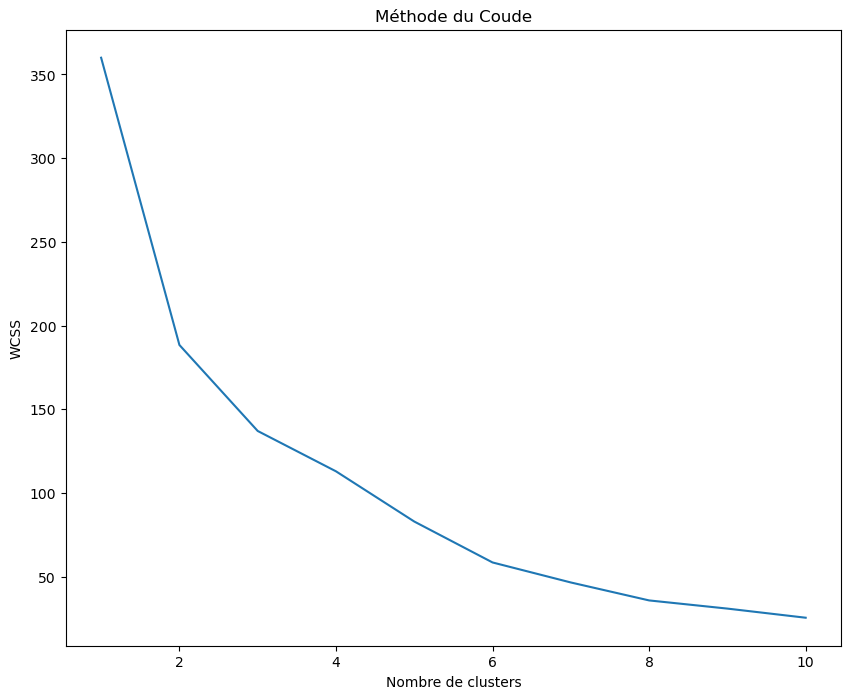

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Supposons que 'df_scaled' est ton DataFrame normalisé

# Calculer la somme des carrés pour un éventail de nombres de clusters
wcss = []
for i in range(1, 11):  # Tester de 1 à 10 clusters, par exemple
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Visualiser la méthode du coude
plt.figure(figsize=(10,8))
plt.plot(range(1, 11), wcss)
plt.title('Méthode du Coude')
plt.xlabel('Nombre de clusters')
plt.ylabel('WCSS')  # Within-Cluster Sum of Squares
plt.show()


In [10]:
# Remplacer 'n_clusters_optimal' par le nombre de clusters optimal trouvé
kmeans_optimal = KMeans(n_clusters=8, init='k-means++', max_iter=300, n_init=10, random_state=0)
df['Cluster'] = kmeans_optimal.fit_predict(df_scaled)


d:\anato\Documents\CNAM\DefiChalenge\.conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
df

,Fichier,Vol,Surf,Lng_BBox,Lrg_BBox,Ht_BBox,Faces,Aretes,Sommets,Cluster
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,213,624,414,2
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,213,624,414,2
2,AR00000233649--D.stp,7.930359e+06,1.821287e+06,579.000000,526.500000,539.500305,608,1574,1034,4
3,AR00000242305.stp,4.678052e+05,1.759273e+05,519.428775,247.348414,279.982795,205,521,322,2
4,AR00000242310.stp,2.802220e+05,1.048190e+05,290.000000,227.000000,25.000000,114,304,184,5
5,AR00000242311.stp,4.401390e+05,1.730978e+05,290.000000,432.700664,25.196153,270,846,564,6
6,AR00000242312.stp,7.608478e+04,3.047107e+04,144.000000,44.000000,80.000000,44,132,88,0
7,AR00000242313.stp,8.318124e+04,3.353410e+04,201.874338,66.000000,177.874687,96,264,170,5
8,AR00000243830.stp,2.171113e+05,8.426894e+04,320.616518,205.000000,151.101007,112,318,210,5
9,AR00000244409.stp,1.678704e+05,6.271524e+04,245.000000,86.631812,187.781038,100,266,168,5


In [16]:
df[['Fichier', 'Cluster']].sort_values(by='Cluster')

,Fichier,Cluster
22,M3D-217580_--A_CATPART_1.stp,0
36,M3D-242439_A.stp,0
31,M3D-226629_--B_CATPART_1.stp,0
26,M3D-217586_--A_CATPART_1.stp,0
6,AR00000242312.stp,0
25,M3D-217585_--A_CATPART_1.stp,0
24,M3D-217583_--A_CATPART_1.stp,0
23,M3D-217582_--A_CATPART_1.stp,0
20,M3D-217571_--A_CATPART_1.stp,0
12,M3D-154775_--A_CATPART_0.stp,0


In [21]:
len(df[df['Cluster']==5])

16

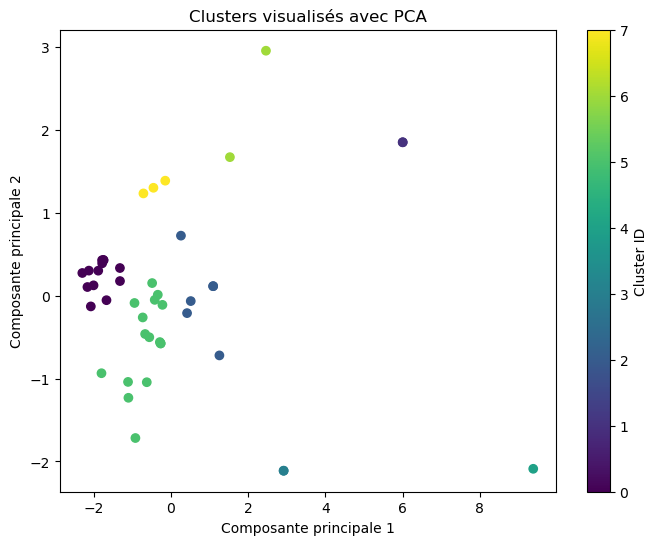

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Appliquer PCA pour réduire à deux dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

# Ajouter les résultats PCA au DataFrame
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Tracer les clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title('Clusters visualisés avec PCA')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.colorbar(label='Cluster ID')
plt.show()


[t-SNE] Computing 44 nearest neighbors...
[t-SNE] Indexed 45 samples in 0.001s...
[t-SNE] Computed neighbors for 45 samples in 0.024s...
[t-SNE] Computed conditional probabilities for sample 45 / 45
[t-SNE] Mean sigma: 4.283217
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.172455
[t-SNE] KL divergence after 300 iterations: 0.004650


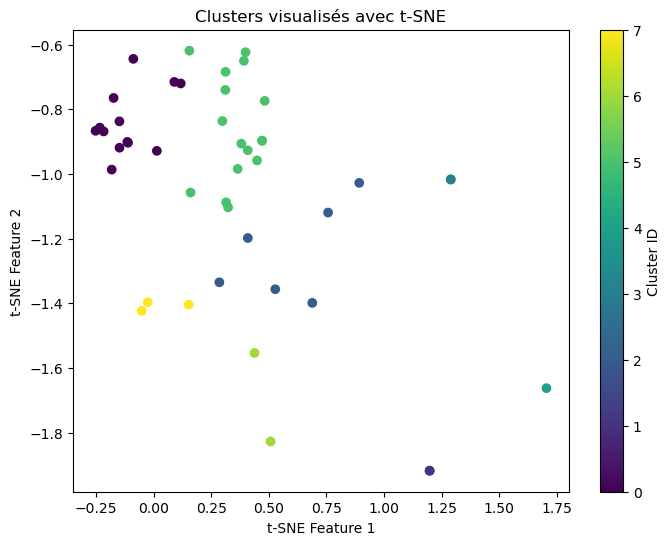

In [14]:
from sklearn.manifold import TSNE

# Appliquer t-SNE pour réduire à deux dimensions
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
tsne_result = tsne.fit_transform(df_scaled)

# Ajouter les résultats t-SNE au DataFrame
df['tSNE1'] = tsne_result[:, 0]
df['tSNE2'] = tsne_result[:, 1]

# Tracer les clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['tSNE1'], df['tSNE2'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title('Clusters visualisés avec t-SNE')
plt.xlabel('t-SNE Feature 1')
plt.ylabel('t-SNE Feature 2')
plt.colorbar(label='Cluster ID')
plt.show()


In [15]:
df.to_csv("3D.csv", index=False,sep=";")